In [312]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import date
from scipy.stats import zscore

Dataset

In [313]:
car_csv = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv"
car_df = pd.read_csv(car_csv)

Next, use only the following columns:
'engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg'

In [314]:
rlvnt_clmns = ["engine_displacement","horsepower","vehicle_weight","model_year",
               "fuel_efficiency_mpg"]
df = car_df[rlvnt_clmns]
df.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='object')

EDA\
Look at the fuel_efficiency_mpg variable. Does it have a long tail?

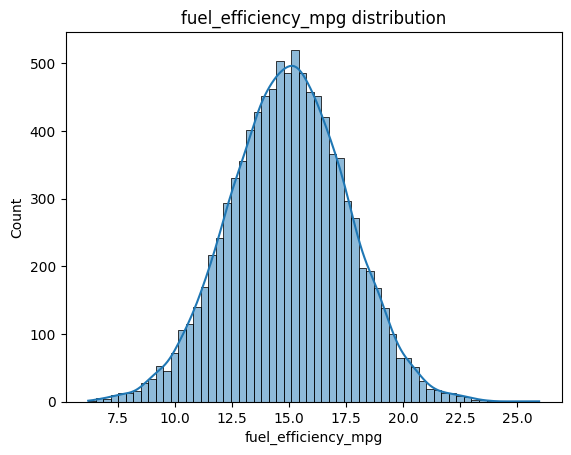

In [315]:
sns.histplot(df.fuel_efficiency_mpg, bins=60, kde=True)
plt.title("fuel_efficiency_mpg distribution")
plt.show()

From the histplot it can be seen that fuel_efficiency_mpg resembles a normal distribution, so no it does not have a long tail

Question 1\
There's one column with missing values. What is it?

In [316]:
missing_column = df.columns[df.isnull().any()]
print(f"The column with missing values is:{missing_column.values}")

The column with missing values is:['horsepower']


Question 2\
What's the median (50% percentile) for variable 'horsepower'?

In [317]:
hp_median = df.horsepower.quantile(0.5)
print(f"The median (50% percentile) of horsepower is: {hp_median}")

The median (50% percentile) of horsepower is: 149.0


Prepare and split the dataset\
Shuffle the dataset (the filtered one you created above), use seed 42.\
Split your data in train/val/test sets, with 60%/20%/20% distribution.\
Use the same code as in the lectures

In [318]:
def split_dataframe(src_df, vldtn_sz=0.2, tst_sz=0.2, seed=42):
    #use seed 42, or other
    gnrtr = np.random.default_rng(seed)
    #data split distribution
    len_df = len(src_df)
    len_vldtn = int(vldtn_sz * len_df)
    len_tst = int(tst_sz * len_df)
    len_trn = len_df - (len_vldtn + len_tst)
    #shuffle data
    idx = np.arange(len_df)
    gnrtr.shuffle(idx)
    shffld_df = src_df.iloc[idx]
    #split dataframe observations
    trn_df = shffld_df.iloc[:len_trn].copy()
    vldtn_df = shffld_df.iloc[len_trn:len_trn+len_vldtn].copy()
    tst_df = shffld_df.iloc[len_trn+len_vldtn:].copy()
    return trn_df, vldtn_df, tst_df

In [319]:
trn_df, vldtn_df, tst_df = split_dataframe(df)

In [320]:
print(f"Observations in train dataframe:{len(trn_df)}")
print(f"Observations in validation dataframe:{len(vldtn_df)}")
print(f"Observations in test dataframe:{len(vldtn_df)}")

Observations in train dataframe:5824
Observations in validation dataframe:1940
Observations in test dataframe:1940


In [321]:
trn_df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
1425,190,135.0,3346.051384,2015,13.046346
7185,270,133.0,3360.818964,2001,13.064209
7477,210,95.0,3205.619985,2011,13.978858
7569,250,168.0,2428.658043,2011,17.960291
2481,160,162.0,3331.376582,2004,13.616607


In [322]:
trn_df.isnull().sum()

engine_displacement      0
horsepower             441
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [323]:
vldtn_df.isnull().sum()

engine_displacement      0
horsepower             116
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [324]:
tst_df.isnull().sum()

engine_displacement      0
horsepower             151
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Question 3\
We need to deal with missing values for the column from Q1 (horsepower).\
We have two options: fill it with 0 or with the mean of this variable.\
Try both options. For each, train a linear regression model without regularization using the code from the lessons.\
For computing the mean, use the training only!\
Use the validation dataset to evaluate the models and compare the RMSE of each option.\
Round the RMSE scores to 2 decimal digits using round(score, 2)\
Which option gives better RMSE?

Start by filling missing values, a dataframe for zero fill and other for mean fill

In [325]:
def zero_fill_splits(split, column):
    split_zero_filled = split.copy()
    split_zero_filled[column] = split_zero_filled[column].fillna(value=0)
    return split_zero_filled

In [326]:
trn_df_zero = zero_fill_splits(trn_df, "horsepower")
vldtn_df_zero = zero_fill_splits(vldtn_df, "horsepower")
tst_df_zero = zero_fill_splits(tst_df, "horsepower")

In [327]:
def mean_fill_splits(trn_split, split, column):
    split_mn_filled = split.copy()
    split_mn_filled[column] = split_mn_filled[column].fillna(value=trn_split[column].mean())
    return split_mn_filled

In [328]:
trn_df_mn = mean_fill_splits(trn_df, trn_df, "horsepower")
vldtn_df_mn = mean_fill_splits(trn_df, vldtn_df, "horsepower")
tst_df_mn = mean_fill_splits(trn_df, tst_df, "horsepower")

Check which dataframes contain missing values

In [329]:
trn_df_zero.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [330]:
vldtn_df_zero.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [331]:
tst_df_zero.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [332]:
trn_df_mn.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [333]:
vldtn_df_mn.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [334]:
tst_df_mn.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

Separate fuel_efficiency_mpg from each filled split

In [335]:
# get y from each split
def split_target(split, column):
    target = split[column].values
    return target

In [336]:
column = "fuel_efficiency_mpg"
trn_zero_y = split_target(trn_df_zero, column)
vldtn_zero_y = split_target(vldtn_df_zero, column)
tst_zero_y = split_target(tst_df_zero, column)

trn_mn_y = split_target(trn_df_mn, column)
vldtn_mn_y = split_target(vldtn_df_mn, column)
tst_mn_y = split_target(tst_df_mn, column)

In [337]:
# get feature matrix X from each split
def isolate_target(split, column):
    del split[column]

In [338]:
isolate_target(trn_df_zero, column)
isolate_target(vldtn_df_zero, column)
isolate_target(tst_df_zero, column)

In [339]:
isolate_target(trn_df_mn, column)
isolate_target(vldtn_df_mn, column)
isolate_target(tst_df_mn, column)

Check final_price is not in train, test, validation splits

In [340]:
print(trn_df_zero.columns)
print(vldtn_df_zero.columns)
print(tst_df_zero.columns)

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='object')
Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='object')
Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='object')


In [341]:
print(trn_df_mn.columns)
print(vldtn_df_mn.columns)
print(tst_df_mn.columns)

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='object')
Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='object')
Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='object')


Feature Engineering (if possible)

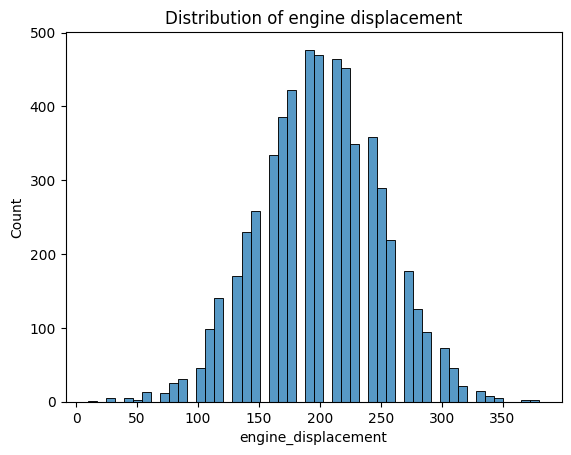

In [342]:
sns.histplot(trn_df_zero.engine_displacement, bins=50)
plt.title("Distribution of engine displacement")
plt.show()

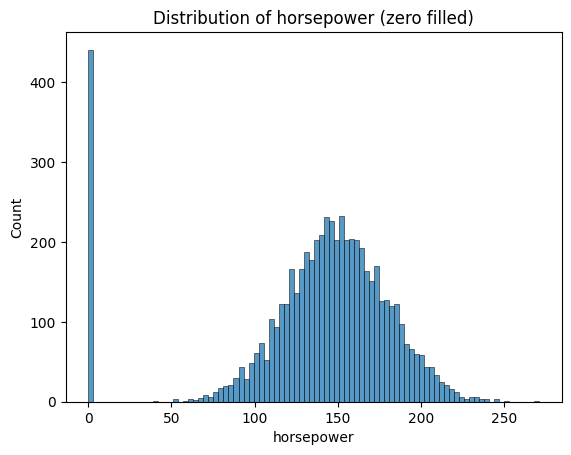

In [343]:
sns.histplot(trn_df_zero.horsepower, bins=90)
plt.title("Distribution of horsepower (zero filled)")
plt.show()

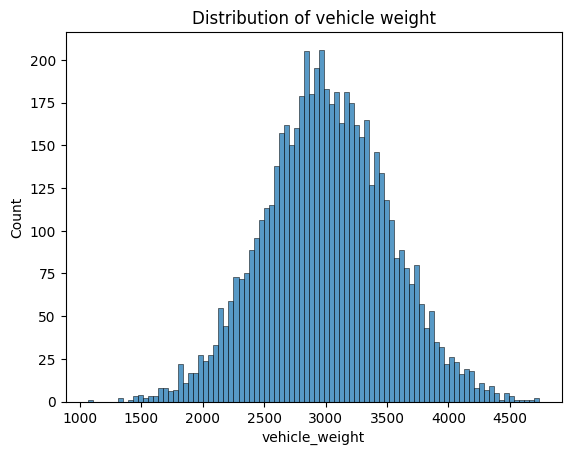

In [344]:
sns.histplot(trn_df_zero.vehicle_weight, bins=90)
plt.title("Distribution of vehicle weight")
plt.show()

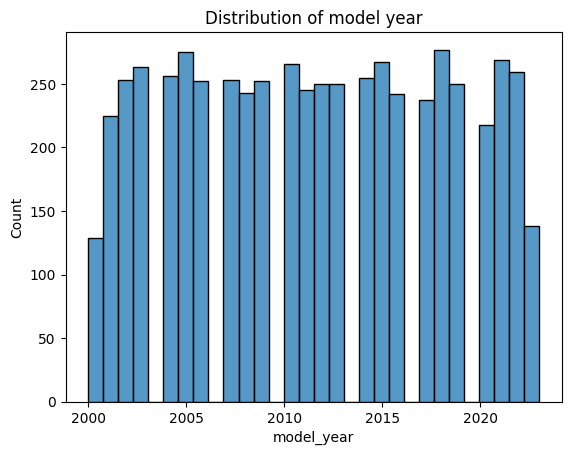

In [345]:
sns.histplot(trn_df_zero.model_year, bins=30)
plt.title("Distribution of model year")
plt.show()

In [346]:
# does it work correctly when the predictor variables have a 'symmetric' distribution?
def z_score_norm(src_df, column):
    return zscore(src_df[column]).tolist()

In [347]:
def simple_feature_eng(src_df):
    ftr_eng_df = src_df.copy()
    ftr_eng_df = ftr_eng_df.reset_index(drop=True)
    ftr_eng_df["eng_dsplcmnt_nrm"] = z_score_norm(ftr_eng_df, "engine_displacement")
    ftr_eng_df["hrspwr_nrm"] = z_score_norm(ftr_eng_df, "horsepower")
    ftr_eng_df["vhcl_wght_nrm"] = z_score_norm(ftr_eng_df, "vehicle_weight")

    year = date.today().year
    ftr_eng_df["age"] = year - ftr_eng_df.model_year
    ftr_eng_df["age"] = z_score_norm(ftr_eng_df, "age")

    del ftr_eng_df["engine_displacement"]
    del ftr_eng_df["horsepower"]
    del ftr_eng_df["vehicle_weight"]
    del ftr_eng_df["model_year"]

    return ftr_eng_df

In [348]:
#all dfs include engineered features from original features
trn_df_zero_eng = simple_feature_eng(trn_df_zero)
vldtn_df_zero_eng = simple_feature_eng(vldtn_df_zero)
tst_df_zero_eng = simple_feature_eng(tst_df_zero)

trn_df_mn_eng = simple_feature_eng(trn_df_mn)
vldtn_df_mn_eng = simple_feature_eng(vldtn_df_mn)
tst_df_mn_eng = simple_feature_eng(tst_df_mn)

In [349]:
# attention to horsepower as imputation is different
print(trn_df_zero_eng.head())
print(trn_df_mn_eng.head())

   eng_dsplcmnt_nrm  hrspwr_nrm  vhcl_wght_nrm       age
0         -0.210787   -0.065381       0.670080 -0.522519
1          1.400002   -0.106327       0.699243  1.581596
2          0.191910   -0.884300       0.392761  0.078657
3          0.997305    0.610228      -1.141558  0.078657
4         -0.814832    0.487390       0.641101  1.130714
   eng_dsplcmnt_nrm  hrspwr_nrm  vhcl_wght_nrm       age
0         -0.210787   -0.506493       0.670080 -0.522519
1          1.400002   -0.576282       0.699243  1.581596
2          0.191910   -1.902274       0.392761  0.078657
3          0.997305    0.645027      -1.141558  0.078657
4         -0.814832    0.435660       0.641101  1.130714


Construct a linear regression (baseline)

In [350]:
#linear regression
def train_lr(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

Train the linear regression for each train split (zero and mean)

In [351]:
#lr for zero filled split
w0_zero, w_zero = train_lr(trn_df_zero_eng, trn_zero_y)
#lr for mean filled split
w0_mn, w_mn = train_lr(trn_df_mn_eng, trn_mn_y)

Predict using each train split (zero and mean)

In [352]:
#lr predictions for zero filled split
prd_zero_y = w0_zero + trn_df_zero_eng.dot(w_zero)
#lr predictions for mean filled split
prd_mn_y = w0_mn + trn_df_mn_eng.dot(w_mn)

Visualize distributions of actual vs predicted

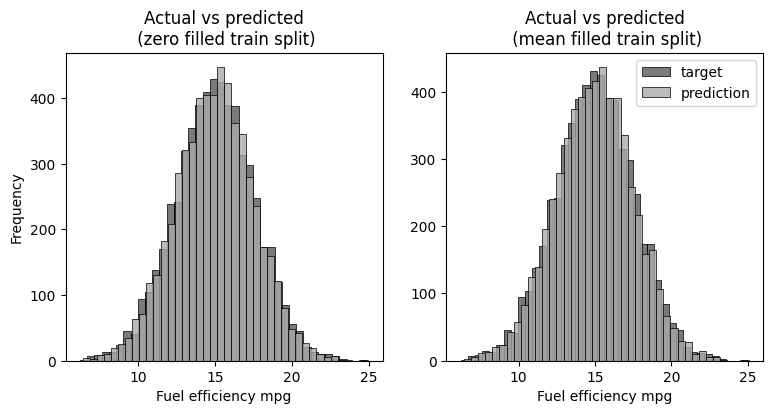

In [353]:
X_LBL = "Fuel efficiency mpg"
Y_LBL = "Frequency"
TRGT = "target"
PRDCT = "prediction"
CLR_1 = "#222222"
CLR_2 = "#aaaaaa"

fig_act_prd, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

sns.histplot(trn_zero_y, label=TRGT, color=CLR_1, alpha=0.6, bins=40, ax=ax1)
sns.histplot(prd_zero_y, label=PRDCT, color=CLR_2, alpha=0.8, bins=40, ax=ax1)
ax1.set_title("Actual vs predicted\n (zero filled train split)")
ax1.set_xlabel(X_LBL)
ax1.set_ylabel(Y_LBL)

sns.histplot(trn_mn_y, label=TRGT, color=CLR_1, alpha=0.6, bins=40, ax=ax2)
sns.histplot(prd_mn_y, label=PRDCT, color=CLR_2, alpha=0.8, bins=40, ax=ax2)
ax2.set_title("Actual vs predicted\n (mean filled train split)")
ax2.set_xlabel(X_LBL)
ax2.set_ylabel("")

plt.legend()
plt.show()

Get RMSE

In [354]:
#rmse, lower is better, predicted values are closer to observed values
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [355]:
rmse_trn_zero = rmse(trn_zero_y, prd_zero_y)
print(rmse_trn_zero)

0.5143822416169052


In [356]:
rmse_trn_mn = rmse(trn_mn_y, prd_mn_y)
print(rmse_trn_mn)

0.4585747151924945


Determine which option gives better rmse

In [357]:
result = None
if rmse_trn_zero == rmse_trn_mn:
    result = f"Both zero and mean are equally good: {rmse_trn_zero}=={rmse_trn_mn} respectively"
elif rmse_trn_zero < rmse_trn_mn:
    result = f"With 0, rmse is {rmse_trn_zero}"
else:
    result = f"With mean, rmse is {rmse_trn_mn}"
print(f"Which option gives better RMSE? {result}")

Which option gives better RMSE? With mean, rmse is 0.4585747151924945


In [358]:
#using validation split
prd_vldtn_zero_y = w0_zero + vldtn_df_zero_eng.dot(w_zero)
prd_vldtn_mn_y = w0_mn + vldtn_df_mn_eng.dot(w_mn)

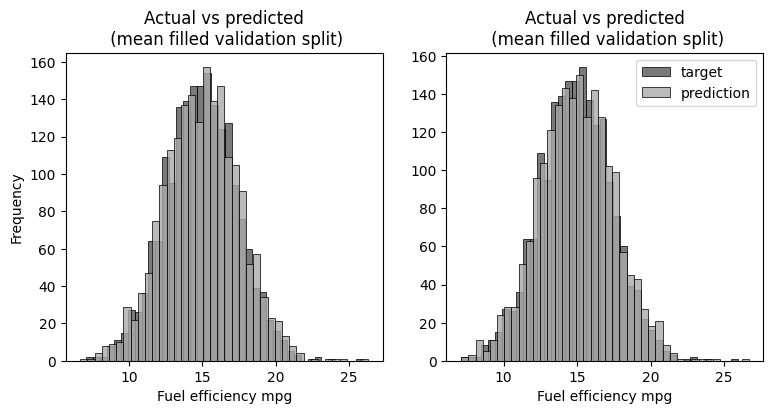

In [359]:
fig_act_prd, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

sns.histplot(vldtn_zero_y, label=TRGT, color=CLR_1, alpha=0.6, bins=40, ax=ax1)
sns.histplot(prd_vldtn_zero_y, label=PRDCT, color=CLR_2, alpha=0.8, bins=40, ax=ax1)
ax1.set_title("Actual vs predicted\n (mean filled validation split)")
ax1.set_xlabel(X_LBL)
ax1.set_ylabel(Y_LBL)

sns.histplot(vldtn_mn_y, label=TRGT, color=CLR_1, alpha=0.6, bins=40, ax=ax2)
sns.histplot(prd_vldtn_mn_y, label=PRDCT, color=CLR_2, alpha=0.8, bins=40, ax=ax2)
ax2.set_title("Actual vs predicted\n (mean filled validation split)")
ax2.set_xlabel(X_LBL)
ax2.set_ylabel("")

plt.legend()
plt.show()

In [360]:
rmse_vldtn_zero = rmse(vldtn_zero_y, prd_vldtn_zero_y)
print(rmse_vldtn_zero)

0.5524739418803009


In [361]:
rmse_vldtn_mn = rmse(vldtn_mn_y, prd_vldtn_mn_y)
print(rmse_vldtn_mn)

0.5059075792341055


Question 4\
Now let's train a regularized linear regression.\
For this question, fill the NAs with 0.\
Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].\
Use RMSE to evaluate the model on the validation dataset.\
Round the RMSE scores to 2 decimal digits.\
Which r gives the best RMSE?\
If there are multiple options, select the smallest r.

Regularized Linear Regression

In [362]:
#regularized linear regression
def train_lr_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg
    
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

Train for different values of r, compare rmse using validdation split and determine best r to use

In [363]:
rmse_scores = {}
rounded_rmse_scores = {}
for r in [0, 0.01, 0.1, 5, 10, 100]:
    w_0, w = train_lr_reg(trn_df_zero_eng, trn_zero_y, r=r)
    print(f"r={r},\t w_0={w_0}, \tw={w[:]}")
    y_pred = w_0 + vldtn_df_zero_eng.dot(w)
    rmse_scores[str(r)] = rmse(vldtn_zero_y, y_pred)
    rounded_rmse_scores[str(r)] = round(rmse(vldtn_zero_y, y_pred),2)

best_r = min(rmse_scores, key=rmse_scores.get)
best_r_rounded = min(rounded_rmse_scores, key=rounded_rmse_scores.get)
print(f"\nBest RMSE is: {rmse_scores.get(best_r)} with r: {best_r}")
print(f"\nBest RMSE rounded is: {rounded_rmse_scores.get(best_r_rounded)} with r: {best_r_rounded}")

r=0,	 w_0=14.95824181146197, 	w=[ 0.01583477  0.16938329 -2.5322446  -0.00596702]
r=0.01,	 w_0=14.958216127711756, 	w=[ 0.01583466  0.16938301 -2.53224025 -0.00596706]
r=0.1,	 w_0=14.957984977928696, 	w=[ 0.01583365  0.16938053 -2.53220111 -0.00596748]
r=5,	 w_0=14.945410929825787, 	w=[ 0.01577902  0.16924561 -2.53007155 -0.00598984]
r=10,	 w_0=14.932602041473181, 	w=[ 0.01572344  0.16910816 -2.52790223 -0.00601258]
r=100,	 w_0=14.705739417615552, 	w=[ 0.01475113  0.16667143 -2.48948123 -0.00640723]

Best RMSE is: 0.5491447211863205 with r: 10

Best RMSE rounded is: 0.55 with r: 0


I forgot to apply the rounding in my first pass and I realized that rounding to 2 decimals makes all values of r give the same RMSE. I wonder if this could be a thing or it is just applied so answers are easy to identify for all participants. Smallest r is zero so no need for regularization? For now depending on the scenario you are facing you can decide whether or not to lose some precision or introduce some error to your findings.

In [364]:
#regularized lr for zero filled splits
w_0, w = train_lr_reg(trn_df_zero_eng, trn_zero_y, r=0)
y_pred = w_0 + trn_df_zero_eng.dot(w)
print(f"trn rmse={rmse(trn_zero_y, y_pred)}")

y_pred = w_0 + vldtn_df_zero_eng.dot(w)
print(f"vldtn rmse={rmse(vldtn_zero_y, y_pred)}")
print(f"vldtn rmse rounded={round(rmse(vldtn_zero_y, y_pred),2)}")

trn rmse=0.5143822416169052
vldtn rmse=0.5524739418803009
vldtn rmse rounded=0.55


In [365]:
w_0, w = train_lr_reg(trn_df_zero_eng, trn_zero_y, r=0.01)
y_pred = w_0 + trn_df_zero_eng.dot(w)
print(f"trn rmse={rmse(trn_zero_y, y_pred)}")

y_pred = w_0 + vldtn_df_zero_eng.dot(w)
print(f"vldtn rmse={rmse(vldtn_zero_y, y_pred)}")
print(f"vldtn rmse rounded={round(rmse(vldtn_zero_y, y_pred),2)}")

trn rmse=0.5143822422765805
vldtn rmse=0.5524700044272061
vldtn rmse rounded=0.55


In [366]:
w_0, w = train_lr_reg(trn_df_zero_eng, trn_zero_y, r=1)
y_pred = w_0 + trn_df_zero_eng.dot(w)
print(f"trn rmse={rmse(trn_zero_y, y_pred)}")

y_pred = w_0 + vldtn_df_zero_eng.dot(w)
print(f"vldtn rmse={rmse(vldtn_zero_y, y_pred)}")
print(f"vldtn rmse rounded={round(rmse(vldtn_zero_y, y_pred),2)}")

trn rmse=0.5143888360855788
vldtn rmse=0.5520862075552313
vldtn rmse rounded=0.55


In [367]:
w_0, w = train_lr_reg(trn_df_zero_eng, trn_zero_y, r=5)
y_pred = w_0 + trn_df_zero_eng.dot(w)
print(f"trn rmse={rmse(trn_zero_y, y_pred)}")

y_pred = w_0 + vldtn_df_zero_eng.dot(w)
print(f"vldtn rmse={rmse(vldtn_zero_y, y_pred)}")
print(f"vldtn rmse rounded={round(rmse(vldtn_zero_y, y_pred),2)}")

trn rmse=0.5145468518583308
vldtn rmse=0.5506569055124539
vldtn rmse rounded=0.55


In [368]:
w_0, w = train_lr_reg(trn_df_zero_eng, trn_zero_y, r=10)
y_pred = w_0 + trn_df_zero_eng.dot(w)
print(f"trn rmse={rmse(trn_zero_y, y_pred)}")

y_pred = w_0 + vldtn_df_zero_eng.dot(w)
print(f"vldtn rmse={rmse(vldtn_zero_y, y_pred)}")
print(f"vldtn rmse rounded={round(rmse(vldtn_zero_y, y_pred),2)}")

trn rmse=0.5150392400099814
vldtn rmse=0.5491447211863205
vldtn rmse rounded=0.55


In [369]:
w_0, w = train_lr_reg(trn_df_zero_eng, trn_zero_y, r=100)
y_pred = w_0 + trn_df_zero_eng.dot(w)
print(f"trn rmse={rmse(trn_zero_y, y_pred)}")

y_pred = w_0 + vldtn_df_zero_eng.dot(w)
print(f"vldtn rmse={rmse(vldtn_zero_y, y_pred)}")
print(f"vldtn rmse rounded={round(rmse(vldtn_zero_y, y_pred),2)}")

trn rmse=0.5746150587516017
vldtn rmse=0.572752089321661
vldtn rmse rounded=0.57


Question 5\
We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.\
Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].\
For each seed, do the train/validation/test split with 60%/20%/20% distribution.\
Fill the missing values with 0 and train a model without regularization.\
For each seed, evaluate the model on the validation dataset and collect the RMSE scores.\
What's the standard deviation of all the scores? To compute the standard deviation, use np.std.\
Round the result to 3 decimal digits (round(std, 3))


In [370]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scrs = np.full(len(seeds), 0.0, dtype=float)
for sd in seeds:
    #train, validate, test splits using each seed value
    trn_df, vldtn_df, tst_df = split_dataframe(df, seed=sd)
    #fill na with zero
    trn_df_zero = zero_fill_splits(trn_df, "horsepower")
    vldtn_df_zero = zero_fill_splits(vldtn_df, "horsepower")
    tst_df_zero = zero_fill_splits(tst_df, "horsepower")
    #split target
    trn_zero_y = split_target(trn_df_zero, column)
    vldtn_zero_y = split_target(vldtn_df_zero, column)
    tst_zero_y = split_target(tst_df_zero, column)
    #isolate target
    isolate_target(trn_df_zero, column)
    isolate_target(vldtn_df_zero, column)
    isolate_target(tst_df_zero, column)
    #simple ftr eng
    trn_df_zero_eng = simple_feature_eng(trn_df_zero)
    vldtn_df_zero_eng = simple_feature_eng(vldtn_df_zero)
    tst_df_zero_eng = simple_feature_eng(tst_df_zero)
    #train lr
    w_0, w = train_lr(trn_df_zero_eng, trn_zero_y)
    #evaluate lr
    y_pred = w_0 + vldtn_df_zero_eng.dot(w)
    #collect rmse score of seed in turn
    rmse_scrs[sd] = rmse(vldtn_zero_y, y_pred)
    

In [371]:
rmse_std = round(np.std(rmse_scrs), 3)
print(f"The std of rmse scores is: ~{rmse_std}")

The std of rmse scores is: ~0.005


Closest answer for me is 0.006

Question 6\
Split the dataset like previously, use seed 9.\
Combine train and validation datasets.\
Fill the missing values with 0 and train a model with r=0.001.\
What's the RMSE on the test dataset?

In [372]:
#train, validate, test splits using each seed value
trn_df, vldtn_df, tst_df = split_dataframe(df, seed=9)
#fill na with zero
trn_df_zero = zero_fill_splits(trn_df, "horsepower")
vldtn_df_zero = zero_fill_splits(vldtn_df, "horsepower")
tst_df_zero = zero_fill_splits(tst_df, "horsepower")
#split target
trn_zero_y = split_target(trn_df_zero, column)
vldtn_zero_y = split_target(vldtn_df_zero, column)
tst_zero_y = split_target(tst_df_zero, column)
#isolate target
isolate_target(trn_df_zero, column)
isolate_target(vldtn_df_zero, column)
isolate_target(tst_df_zero, column)
#combine train and validation df
cmbnd_df_zero = pd.concat([trn_df_zero, vldtn_df_zero], axis=0).reset_index(drop=True)
cmbnd_df_zero_y = np.concatenate([trn_zero_y, vldtn_zero_y])
#simple ftr eng
cmbnd_df_zero_eng = simple_feature_eng(cmbnd_df_zero)
tst_df_zero_eng = simple_feature_eng(tst_df_zero)
#train lr
w_0, w = train_lr_reg(cmbnd_df_zero_eng, cmbnd_df_zero_y, r=0.001)
#evaluate lr
y_pred = w_0 + tst_df_zero_eng.dot(w)
cmbnd_rmse_scr = rmse(tst_zero_y, y_pred)

In [373]:
print(f"The rmse on the test dataset is: ~{cmbnd_rmse_scr}")

The rmse on the test dataset is: ~0.5046278627976915


Closest value for me is 0.515